# Legnini Evaluation

In [121]:
import scanpy as sc
import numpy as np

import InterScale as interscale
from InterScale.config import load_config
from graph_transformer_long_range_niches.pp import split_adata
from InterScale.tl import prepare_geome_dataset, check_and_update_cfg
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.eval.clustering import leiden_cluster_embeddings, plot_clustering_metrics
from InterScale._paths import get_default_config, HOME_LRZ, PROJECT_LRZ

from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

## Load pretrained models

In [2]:
RESULTS_DIR = '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/results/legnini23/model'

In [114]:
CFG = HOME_LRZ.joinpath("src/config_files/Legnini23/legnini23_genes_sample_GlobalModel.yaml")

/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/config_files/Legnini23/legnini23_genes_sample_GlobalModel.yaml


In [116]:
cfg = load_config(CFG)

In [117]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [118]:
adata.obsm['spatial']

array([[2369.601, 1167.102],
       [4930.774, 1151.607],
       [2274.517, 1143.662],
       ...,
       [3625.728, 7206.087],
       [3170.51 , 7260.791],
       [3495.327, 7333.994]])

In [119]:
interscale.model.LocalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs =  cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label, view_registry = False)
local_model = interscale.model.LocalModel.load(RESULTS_DIR, adata, cfg, local_component = True, global_component = False)
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs =  cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label, view_registry = False)
combined_model = interscale.model.CombinedModel.load(RESULTS_DIR, adata, cfg, local_component = True, global_component = True)

Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


## Inference 

In [7]:
sub_adata = adata[adata.obs['condition'] == 'SHH']

In [122]:
result = local_model.get_model_output(adata, prefix = 'local')

call new


In [123]:
result = combined_model.get_model_output(result, prefix = 'combined')

call new
2001
1695
2001
1702
2001
2001
2001
1641
1959
2001
2001
2001
2001
1985
2001
1780
1644


In [10]:
result

AnnData object with n_obs × n_vars = 31966 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_key', 'combined_cls'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', 'local_local_emb', 'local_decoder_weight', 'combined_local_emb', 'combined_global_emb', 'combined_attn_matrix', 'combined_decoder_weight'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', 'local_y_pred', 'combined_y_pred'

# Compare Local and Global embedding

First we check whether the local and global embedding capture different structures.

Removing 11363 observations with all-NaN global embeddings
New shape: (32399, 88)


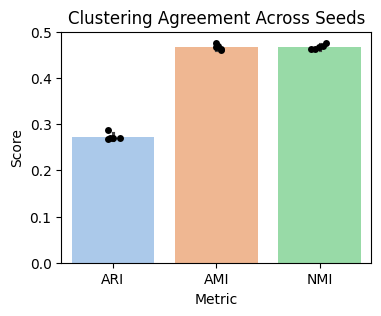

{'ARI': [0.26810934792298463,
  0.2693002896473317,
  0.2862692355885153,
  0.2706902785555352,
  0.26965587101493427],
 'AMI': [0.4618066030567822,
  0.4682166374372833,
  0.47514652892243775,
  0.4666900795294589,
  0.46084608444253866],
 'NMI': [0.4624600622280142,
  0.46878988285185186,
  0.4757973692863618,
  0.46735493411603046,
  0.4615541847051423]}

In [124]:
leiden_cluster_embeddings(result)

## Gene Rank analysis

/ictstr01/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/InterScale/eval/gene_rank_analysis.py:41: RuntimeWarning: invalid value encountered in log
  r2_scores_log = [np.log(r2 + 1) for r2 in r2_scores if not np.isnan(r2)]


Top 5 genes for local_y_pred model:
     gene        r2    r2_log  r2_rank
35  HEY1  0.002487  0.002484     88.0
36  HHIP  0.001574  0.001572     87.0
19  DLX2  0.001364  0.001363     86.0
23  FOSB -0.002522 -0.002525     85.0
34  HES6 -0.003149 -0.003154     84.0


/ictstr01/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/InterScale/eval/gene_rank_analysis.py:41: RuntimeWarning: invalid value encountered in log
  r2_scores_log = [np.log(r2 + 1) for r2 in r2_scores if not np.isnan(r2)]


Top 5 genes for combined_y_pred model:
      gene        r2    r2_log  r2_rank
65   PAX7  0.006775  0.006752     88.0
16   CUX2 -0.002629 -0.002632     87.0
57  NR4A2 -0.006168 -0.006187     86.0
73    SHH -0.007553 -0.007581     85.0
17   DBX1 -0.009776 -0.009824     84.0


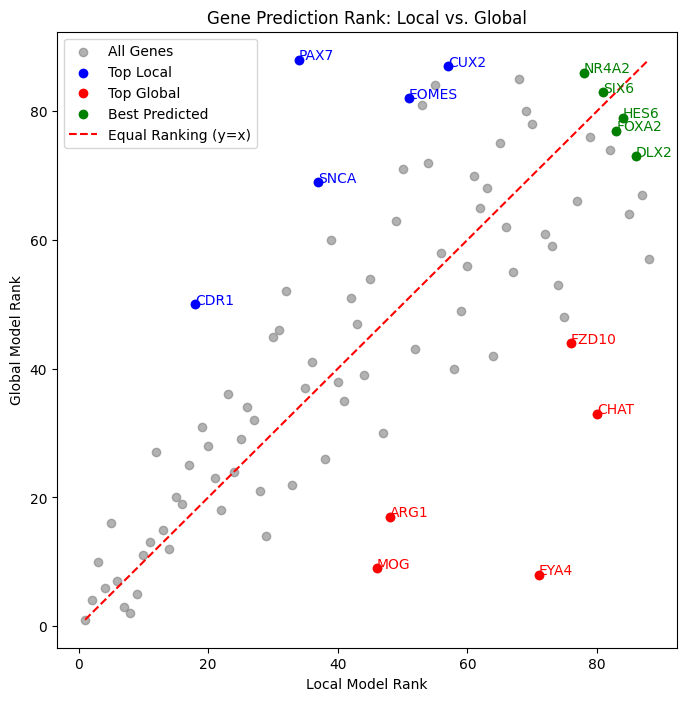

(     gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 65   PAX7        34.0         88.0            -54.0      61.0
 10   CDR1        18.0         50.0            -32.0      34.0
 76   SNCA        37.0         69.0            -32.0      53.0
 20  EOMES        51.0         82.0            -31.0      66.5
 16   CUX2        57.0         87.0            -30.0      72.0,
      gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 21   EYA4        71.0          8.0             63.0      39.5
 11   CHAT        80.0         33.0             47.0      56.5
 48    MOG        46.0          9.0             37.0      27.5
 28  FZD10        76.0         44.0             32.0      60.0
 6    ARG1        48.0         17.0             31.0      32.5,
      gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 57  NR4A2        78.0         86.0             -8.0      82.0
 74   SIX6        81.0         83.0             -2.0      82.0
 34   HES6        84.0         79.0              5.0 

In [11]:
gene_rank_analysis(result,
                   layers_local_pred = 'local_y_pred',
                   layers_global_pred = 'combined_y_pred',
                   top_n = 5,
                   plot_result = True,
                   return_top_genes = True)